# Xử lý graph Ablation Study


## Thư viện cần thiết


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## Truyền dữ liệu từ VI-Ablation Study


Lấy từng ticker ứng với từng folder và từng case trong kết quả ablation đã có.


In [2]:
# Tìm thư mục dữ liệu dù notebook được chạy từ JOURNAL_2026 hay từ thư mục gốc dự án.
def find_ablation_dir(start: Path) -> Path:
    start = start.resolve()
    relative_locations = (
        Path('VI-Ablation Study/kq_albation'),
        Path('application/JOURNAL_2026/VI-Ablation Study/kq_albation'),
    )
    for parent in (start, *start.parents):
        for relative in relative_locations:
            candidate = parent / relative
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError('Không tìm thấy thư mục VI-Ablation Study/kq_albation.')


ABLATION_DIR = find_ablation_dir(Path.cwd())
CASES = (
    'without_vae',
    'without_cost_network',
    'without_confident_weighting',
)
CASE_LABELS = {
    'without_vae': 'Without VAE',
    'without_cost_network': 'Without Cost Network',
    'without_confident_weighting': 'Without Confidence Weighting',
}

# Mỗi thư mục cấp một là một ticker; chỉ nhận ticker có đủ summary của cả 3 case.
summary_files = {}
for ticker_dir in sorted(path for path in ABLATION_DIR.iterdir() if path.is_dir()):
    files = {
        case: ticker_dir / case / 'ablation_summary.csv'
        for case in CASES
    }
    if all(path.is_file() for path in files.values()):
        summary_files[ticker_dir.name] = files

if not summary_files:
    raise FileNotFoundError(
        f'Không tìm thấy ablation_summary.csv cho đủ 3 case trong {ABLATION_DIR}'
    )

frames = []
for ticker, files in summary_files.items():
    for case, csv_path in files.items():
        frame = pd.read_csv(csv_path)
        frame['_ticker'] = ticker
        frame['_case'] = case
        frames.append(frame)

ablation_results = pd.concat(frames, ignore_index=True)
TICKERS = tuple(summary_files)

expected_rows = len(TICKERS) * len(CASES)
if len(ablation_results) != expected_rows:
    raise ValueError(
        f'Kỳ vọng {expected_rows} dòng summary nhưng nhận được {len(ablation_results)}.'
    )

periods = sorted(ablation_results['period'].astype(str).str.upper().unique())
if periods != ['BAD']:
    raise ValueError(f'Dữ liệu ablation phải thuộc BAD period, nhận được: {periods}')

print(
    f'Đã nạp {len(frames)} file cho {len(TICKERS)} ticker '
    f'và {len(CASES)} case: {", ".join(TICKERS)}'
)


Đã nạp 18 file cho 6 ticker và 3 case: ACB, FPT, GAS, HPG, SSI, VCB


## Vẽ biểu đồ kết quả


Mục tiêu hình vẽ: Vẽ biểu đồ cột cho mỗi độ đo của bài ablation study, lấy từ các ticker ở mỗi case. Chỉ lấy 6 độ đo chính giống notebook kết quả chính: Profit, ROI %, ARR %, Sharpe Ratio, Max Drawdown và Violation. Đơn vị được trình bày đầy đủ: Profit (%), ROI (%), ARR (%), Sharpe Ratio, Max Drawdown (%) và Violation (count). Không cần tựa đề trong biểu đồ. Dữ liệu ablation hiện có BAD period; mỗi case được phân bằng một cell Markdown và có một hình riêng. Trong mỗi độ đo, 6 cột tương ứng với 6 ticker và dùng màu nhất quán giữa các case. Không tạo thêm file, chỉ hiển thị hình trong output notebook.


In [3]:
# Cột dữ liệu và nhãn đầy đủ, giữ đúng rule của notebook kết quả chính.
METRICS = (
    ('test_profit_mean', 'Profit (%)'),
    ('test_roi_mean', 'ROI (%)'),
    ('test_arr_mean', 'ARR (%)'),
    ('test_sharpe_mean', 'Sharpe Ratio'),
    ('test_max_drawdown_mean', 'Max Drawdown (%)'),
    ('test_violations_mean', 'Violation (count)'),
)
TICKER_COLORS = {
    ticker: color for ticker, color in zip(
        TICKERS,
        ('#2878B5', '#F28E2B', '#59A14F', '#E15759', '#B07AA1', '#76B7B2'),
    )
}

required_columns = {'_ticker', '_case', 'period'} | {column for column, _ in METRICS}
missing_columns = required_columns - set(ablation_results.columns)
if missing_columns:
    raise KeyError(f'Thiếu các cột bắt buộc: {sorted(missing_columns)}')


def annotate_bar(ax, bar, value):
    """Ghi giá trị trung bình lên từng cột."""
    if not np.isfinite(value):
        return
    offset = 4 if value >= 0 else -4
    ax.annotate(
        f'{value:,.2f}',
        (bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, offset),
        textcoords='offset points',
        ha='center',
        va='bottom' if value >= 0 else 'top',
        fontsize=8.5,
        clip_on=False,
    )


def plot_ablation_case(case):
    """Một case tạo một hình 2 x 3, mỗi panel chứa đủ 6 ticker."""
    case_data = (
        ablation_results.loc[ablation_results['_case'].eq(case)]
        .drop_duplicates('_ticker', keep='last')
        .set_index('_ticker')
        .reindex(TICKERS)
    )
    metric_columns = [column for column, _ in METRICS]
    if case_data[metric_columns].isna().all(axis=None):
        raise ValueError(f'Case {case} không có dữ liệu metric hợp lệ.')

    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), constrained_layout=True)
    x = np.arange(len(TICKERS), dtype=float)

    for ax, (column, label) in zip(axes.flat, METRICS):
        values = pd.to_numeric(case_data[column], errors='coerce').to_numpy(dtype=float)
        bars = ax.bar(
            x,
            values,
            width=0.68,
            color=[TICKER_COLORS[ticker] for ticker in TICKERS],
            edgecolor='white',
            linewidth=0.8,
            zorder=3,
        )
        for bar, value in zip(bars, values):
            annotate_bar(ax, bar, value)

        ax.set_ylabel(label)
        ax.set_xticks(x, TICKERS)
        ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
        ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.2f}'))
        ax.margins(y=0.24)

    # Không đặt title/suptitle; tên case nằm ở cell Markdown ngay phía trên.
    plt.show()
    plt.close(fig)


### Case 1 — Without VAE (`without_vae`)

Kết quả BAD period khi loại bỏ thành phần VAE trên toàn bộ 6 ticker.


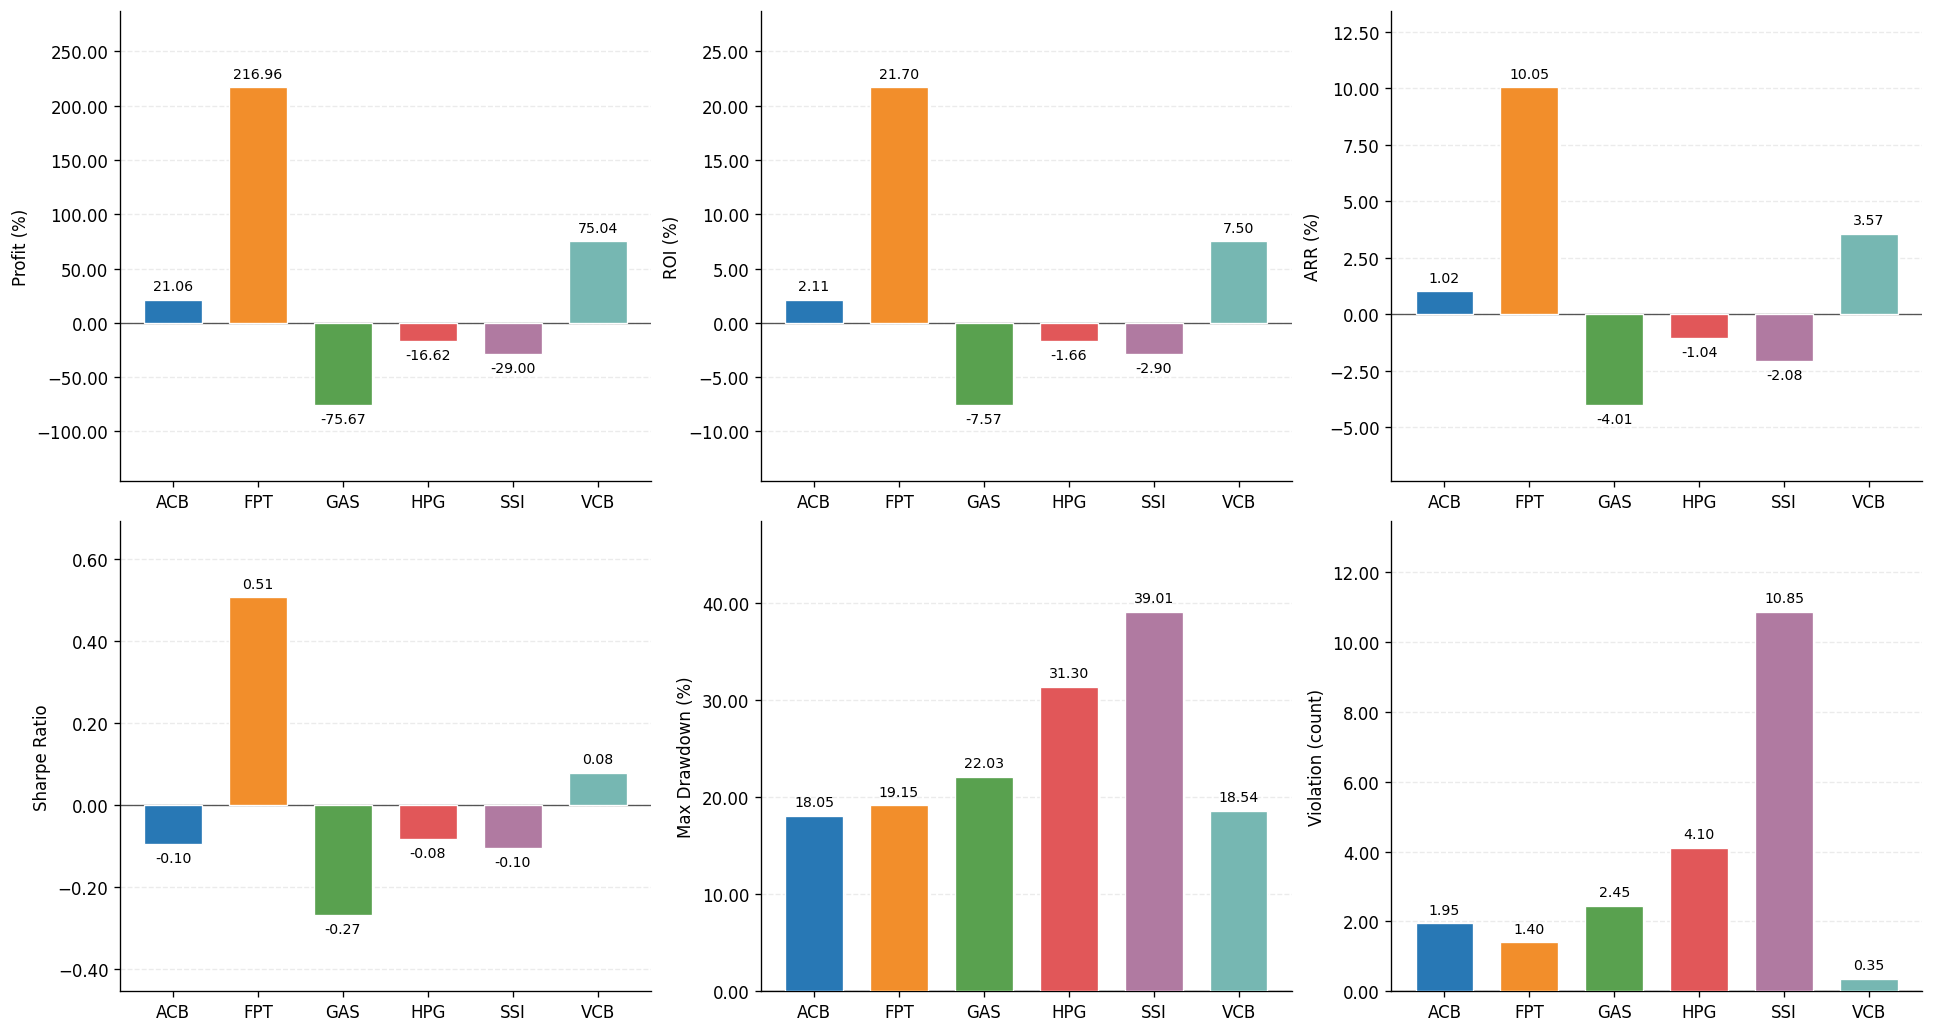

In [4]:
plot_ablation_case('without_vae')


### Case 2 — Without Cost Network (`without_cost_network`)

Kết quả BAD period khi loại bỏ Cost Network trên toàn bộ 6 ticker.


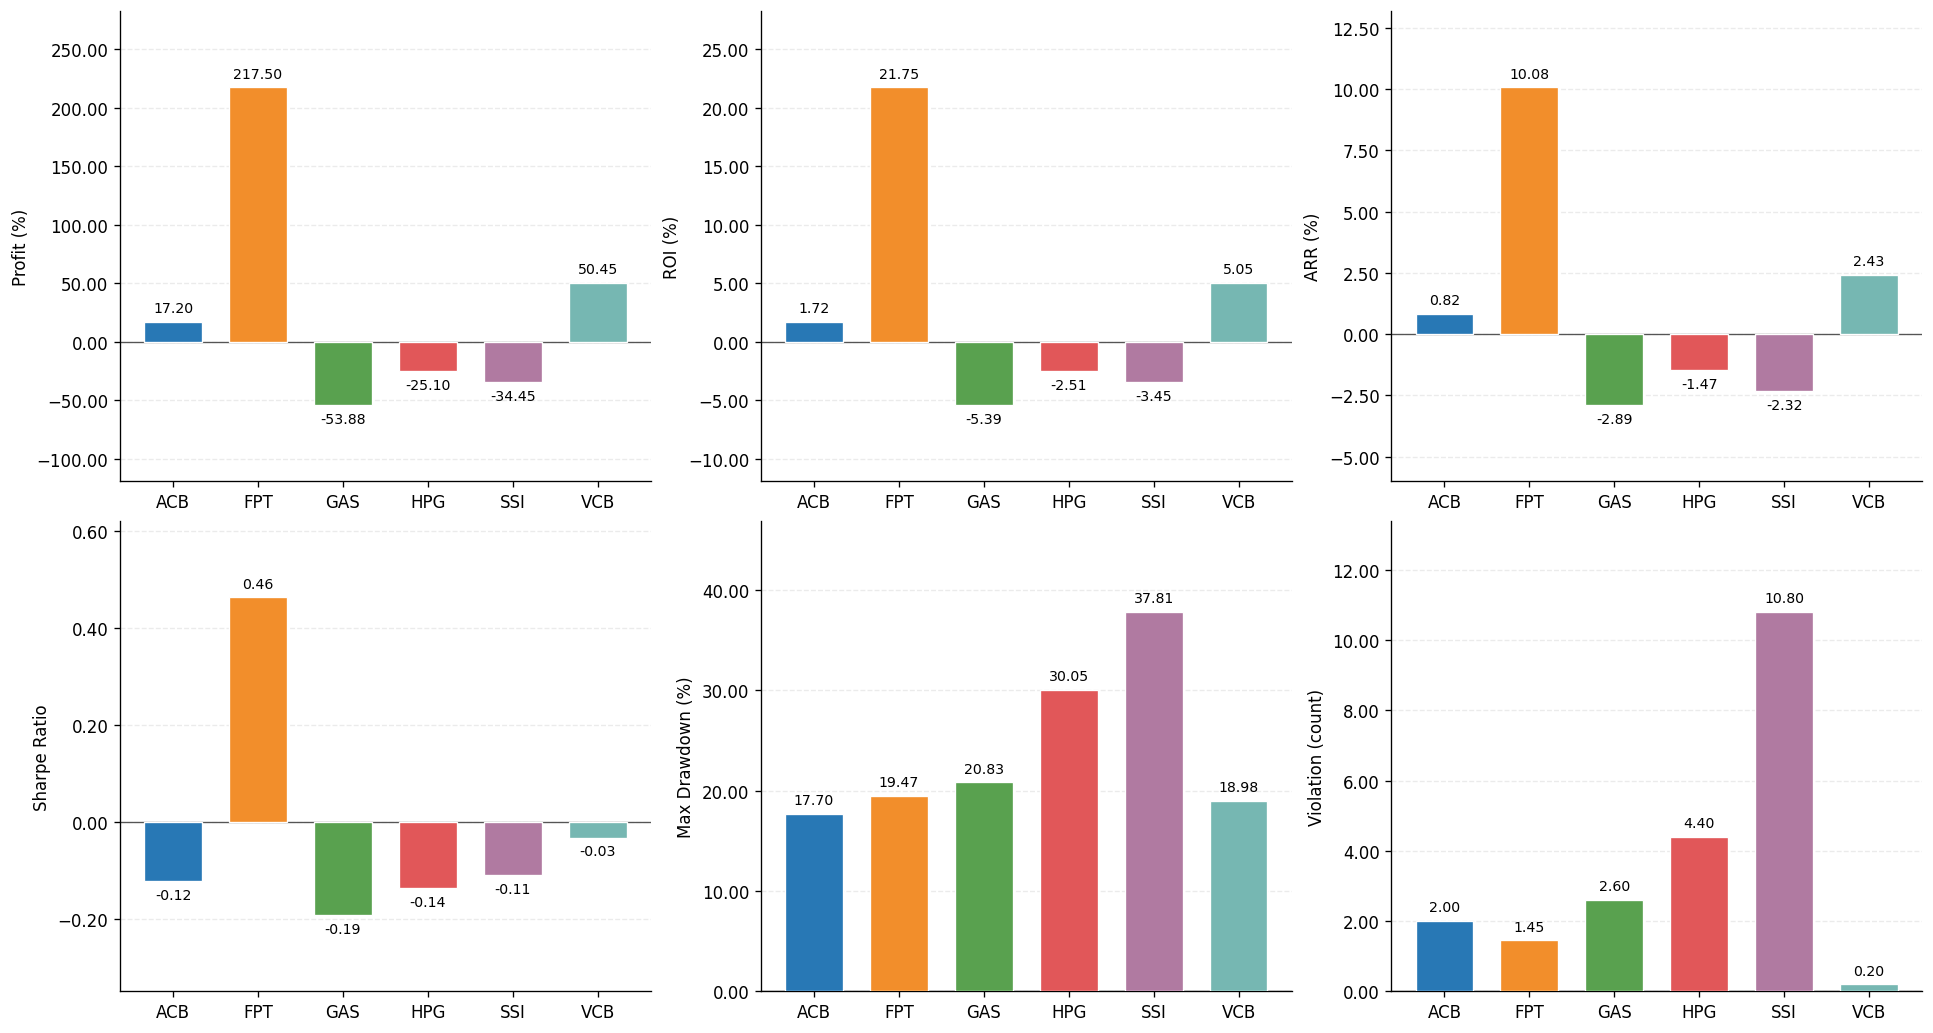

In [5]:
plot_ablation_case('without_cost_network')


### Case 3 — Without Confidence Weighting (`without_confident_weighting`)

Kết quả BAD period khi loại bỏ Confidence Weighting trên toàn bộ 6 ticker.


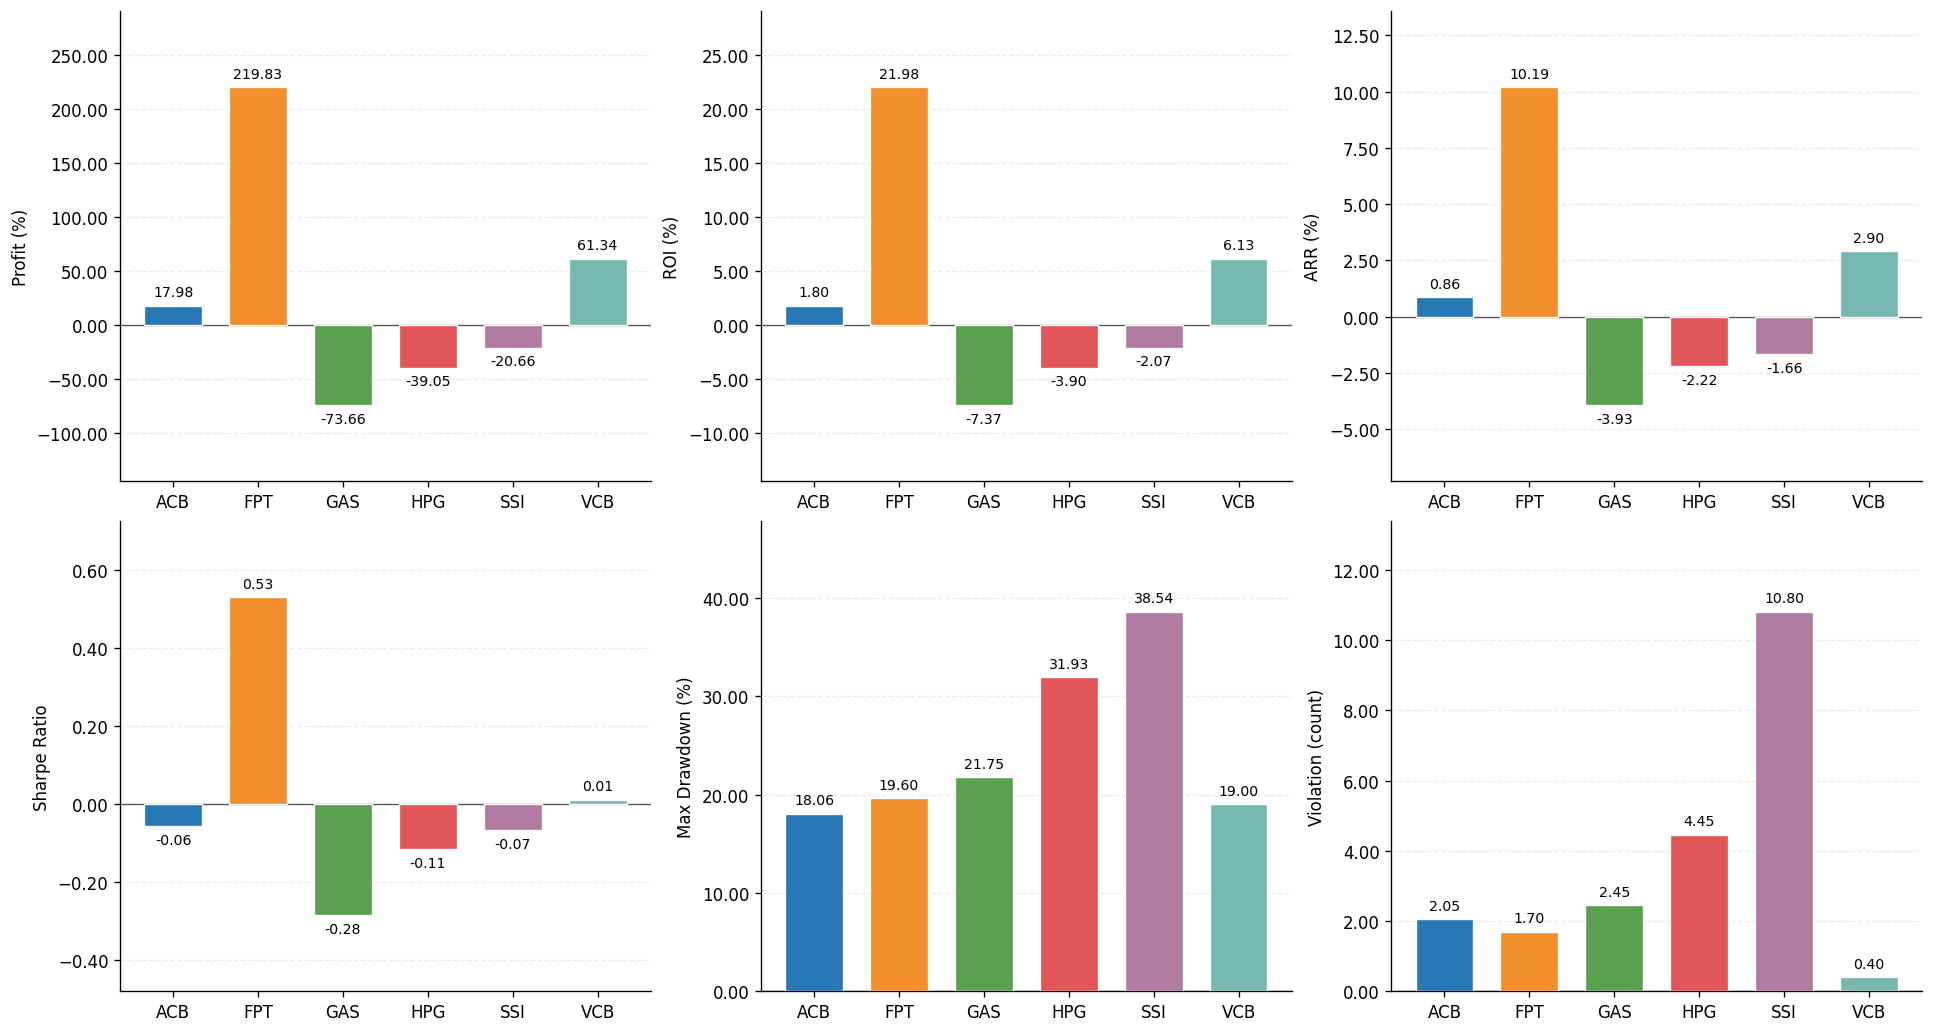

In [6]:
plot_ablation_case('without_confident_weighting')


## So sánh các metrics nhưng giữa các case, cùng metrc, khác case và nhấn mạnh các ảnh hưởng của mỗi case đến các metrics. Từ đó rút ra kết luận về tầm quan trọng của từng thành phần trong mô hình.

Vẽ plot theo mô tả, cũng cho 6 cổ phiếu, nhưng cho mỗi metrics mỗi case. Tổng là 6 hình

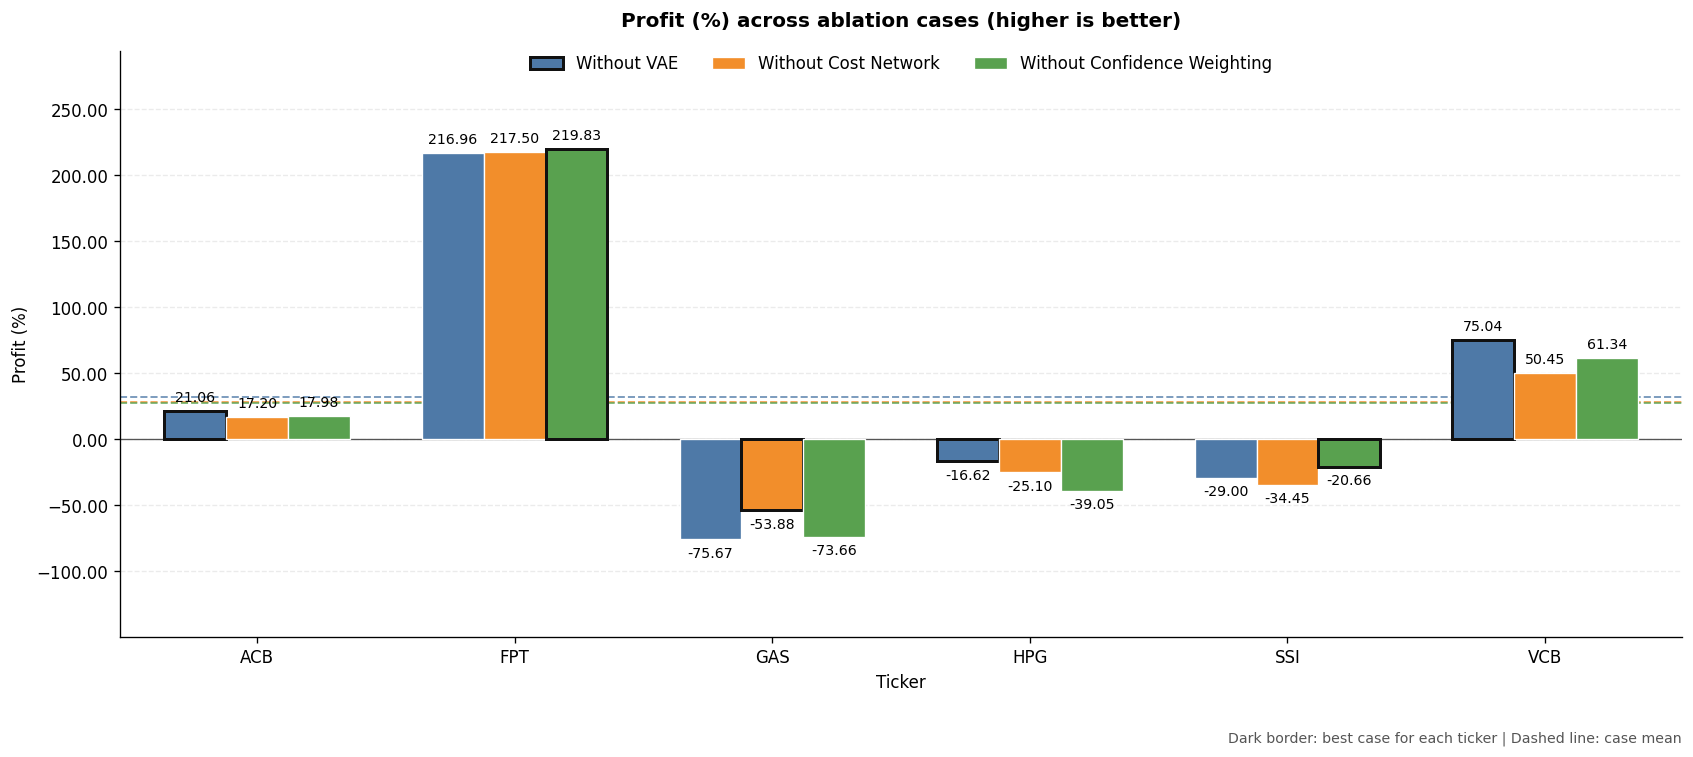

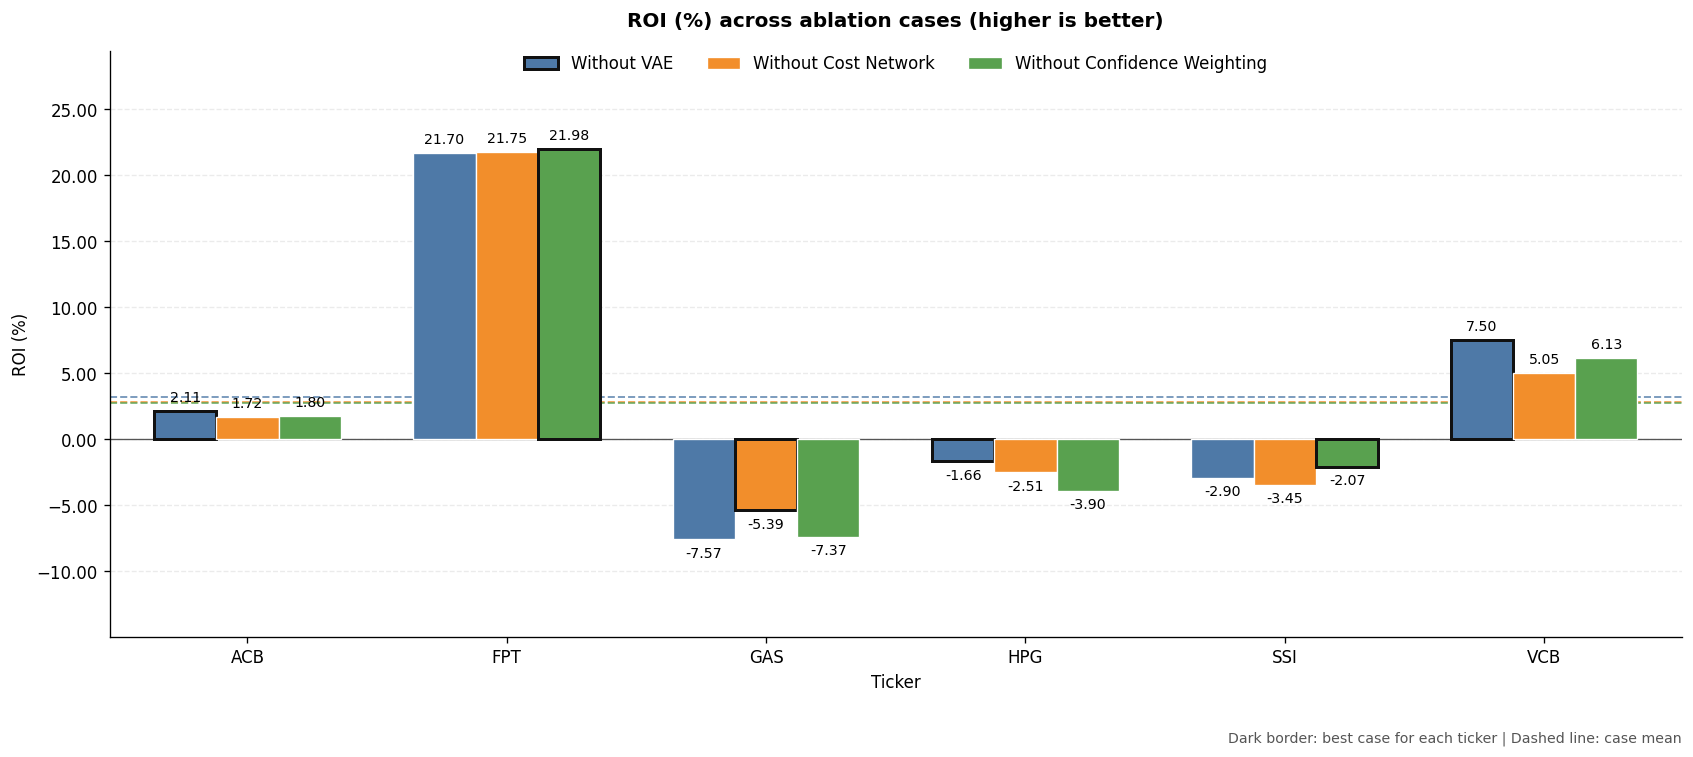

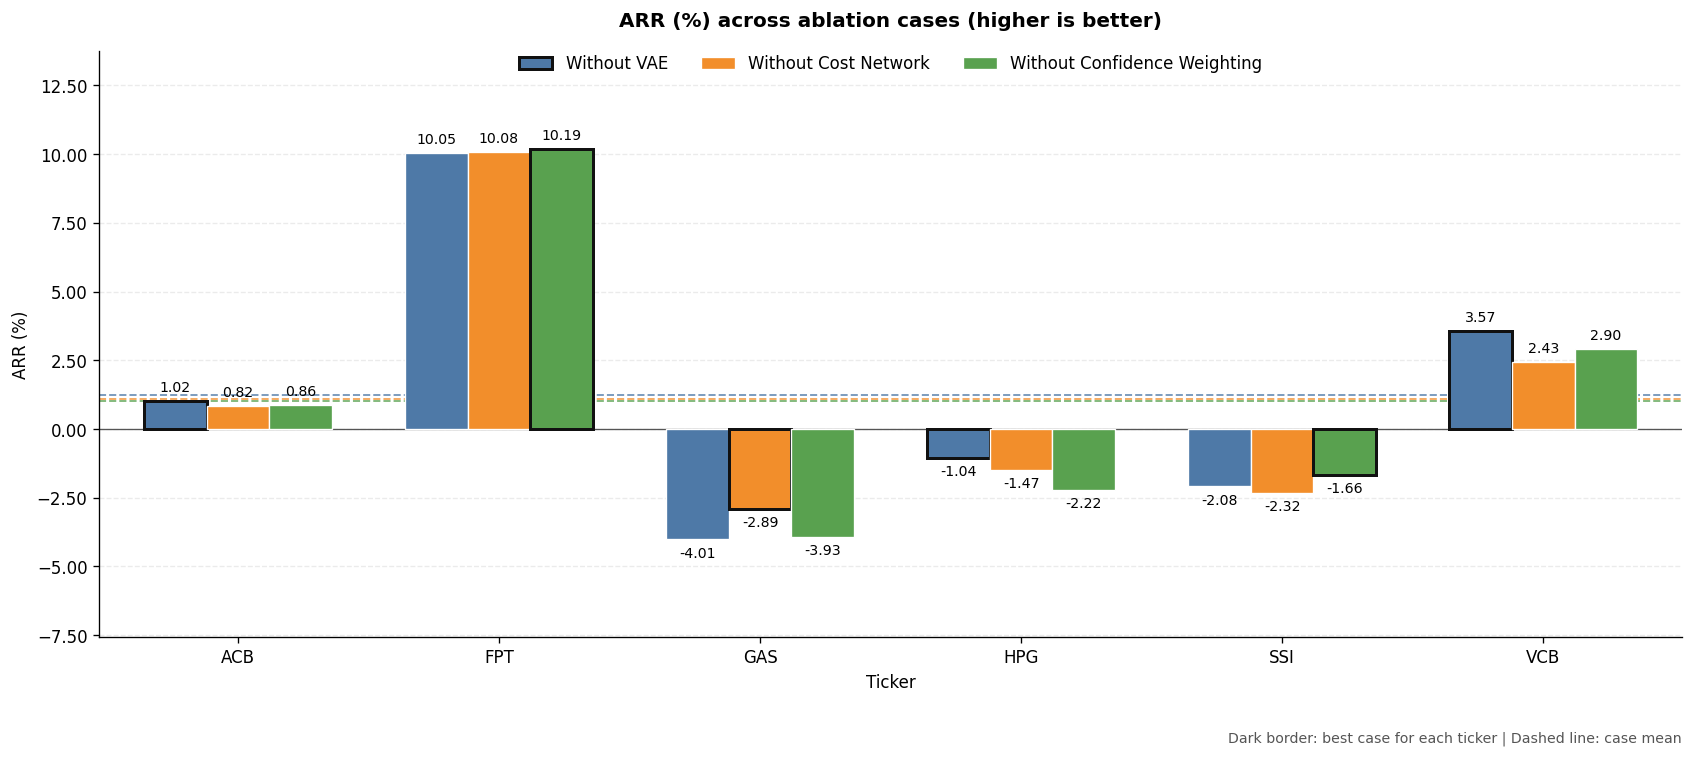

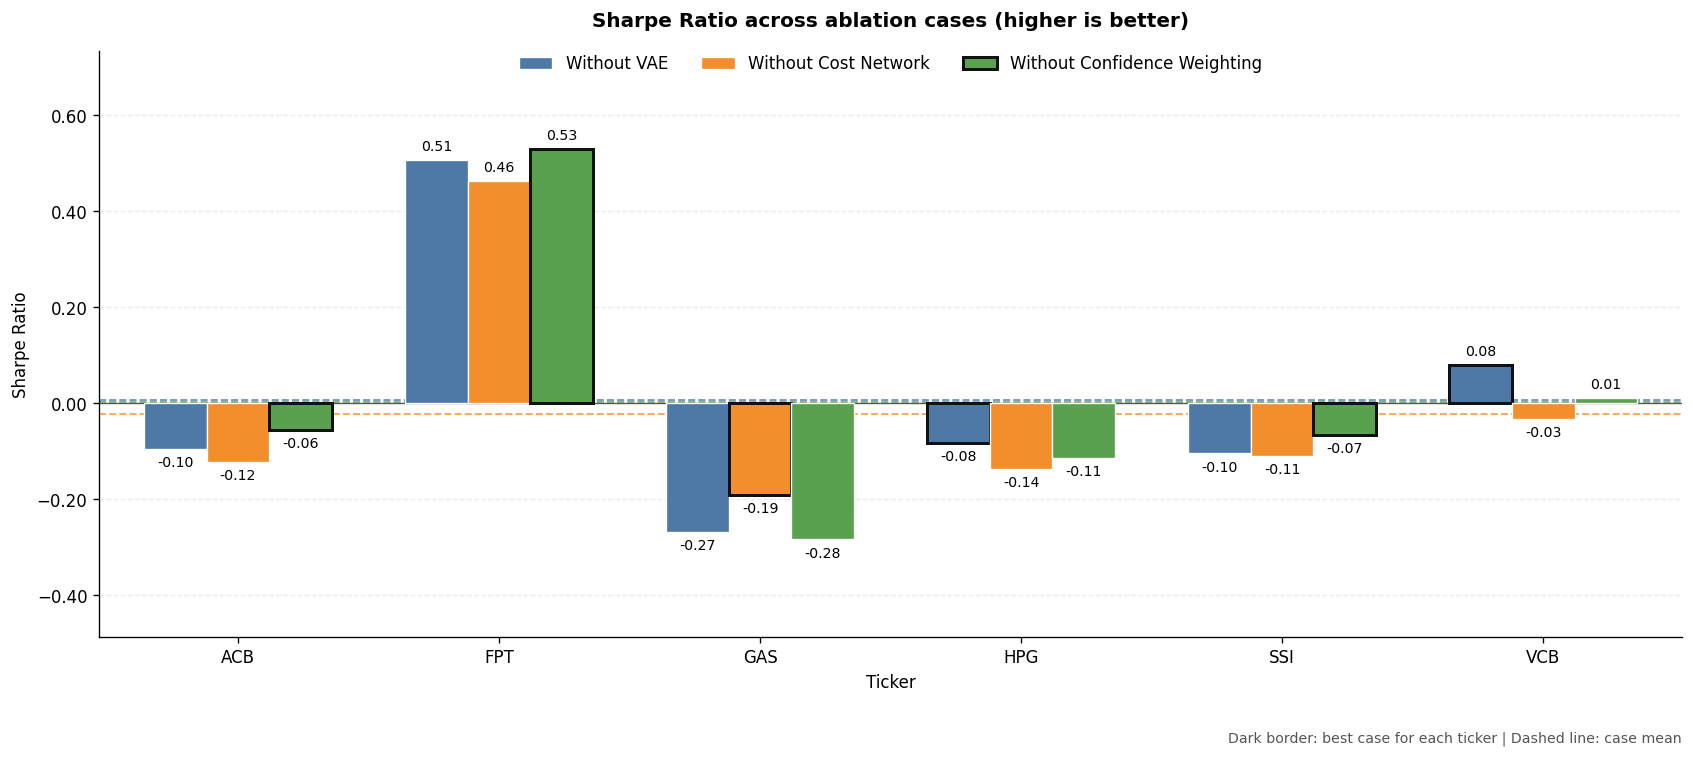

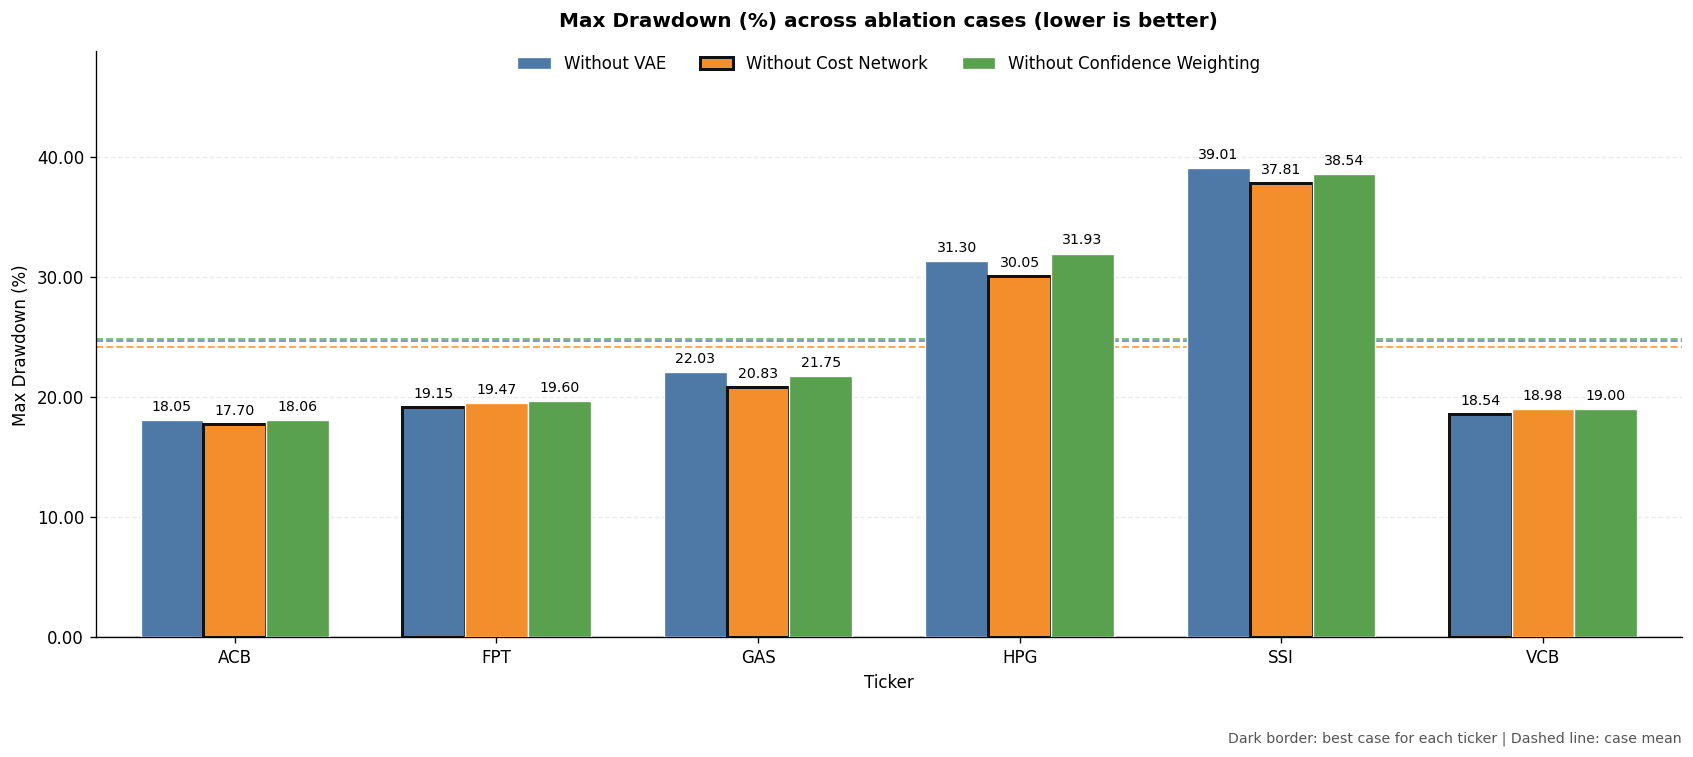

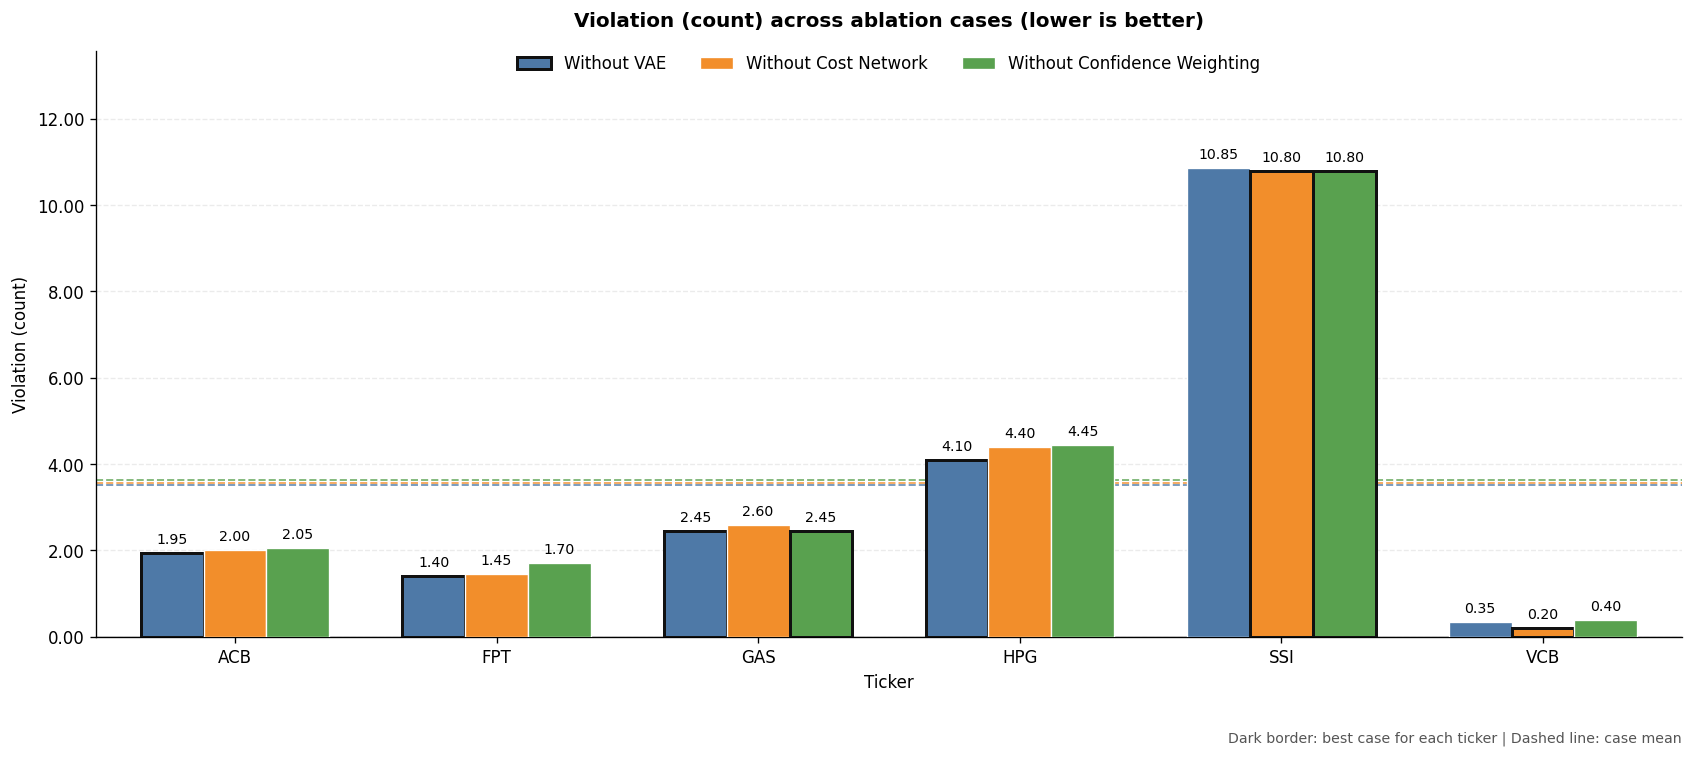

In [7]:
# Mỗi metric tạo một hình: 6 ticker x 3 ablation case.
CASE_COLORS = {
    'without_vae': '#4E79A7',
    'without_cost_network': '#F28E2B',
    'without_confident_weighting': '#59A14F',
}

# Với Profit/ROI/ARR/Sharpe: lớn hơn là tốt hơn.
# Với Max Drawdown/Violation: nhỏ hơn là tốt hơn.
LOWER_IS_BETTER = {'test_max_drawdown_mean', 'test_violations_mean'}


def plot_metric_across_cases(column, label):
    comparison = (
        ablation_results
        .drop_duplicates(['_ticker', '_case'], keep='last')
        .pivot(index='_ticker', columns='_case', values=column)
        .reindex(index=TICKERS, columns=CASES)
        .apply(pd.to_numeric, errors='coerce')
    )

    if comparison.isna().all(axis=None):
        raise ValueError(f'Metric {column} không có dữ liệu hợp lệ.')

    fig, ax = plt.subplots(figsize=(14, 6.2), constrained_layout=True)
    x = np.arange(len(TICKERS), dtype=float)
    width = 0.24
    offsets = (np.arange(len(CASES)) - (len(CASES) - 1) / 2) * width

    values_matrix = comparison.to_numpy(dtype=float)
    best_values = (
        np.nanmin(values_matrix, axis=1)
        if column in LOWER_IS_BETTER
        else np.nanmax(values_matrix, axis=1)
    )

    for offset, case in zip(offsets, CASES):
        values = comparison[case].to_numpy(dtype=float)
        bars = ax.bar(
            x + offset,
            values,
            width=width,
            label=CASE_LABELS[case],
            color=CASE_COLORS[case],
            edgecolor=['#111111' if np.isclose(value, best, equal_nan=False) else 'white'
                       for value, best in zip(values, best_values)],
            linewidth=[1.8 if np.isclose(value, best, equal_nan=False) else 0.8
                       for value, best in zip(values, best_values)],
            zorder=3,
        )
        for bar, value in zip(bars, values):
            annotate_bar(ax, bar, value)

        # Đường nét đứt biểu diễn trung bình trên 6 ticker của case.
        case_mean = np.nanmean(values)
        ax.axhline(
            case_mean, color=CASE_COLORS[case], linestyle='--',
            linewidth=1.15, alpha=0.75, zorder=2,
        )

    direction = 'lower is better' if column in LOWER_IS_BETTER else 'higher is better'
    ax.set_title(f'{label} across ablation cases ({direction})', pad=15, weight='bold')
    ax.set_xlabel('Ticker')
    ax.set_ylabel(label)
    ax.set_xticks(x, TICKERS)
    ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.2f}'))
    ax.margins(x=0.03, y=0.25)
    ax.legend(
        loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(CASES),
        frameon=False,
    )
    ax.text(
        1.0, -0.16,
        'Dark border: best case for each ticker | Dashed line: case mean',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#555555',
    )

    plt.show()
    plt.close(fig)


for metric_column, metric_label in METRICS:
    plot_metric_across_cases(metric_column, metric_label)


Bảng thống kê Toàn bộ các metrics (có std của từng metrics)

In [13]:
from IPython.display import display

# Ghép đúng cột Mean với cột Std tương ứng của cả 6 metrics.
METRIC_STAT_COLUMNS = []
for mean_column, metric_label in METRICS:
    std_column = mean_column.replace('_mean', '_std')
    METRIC_STAT_COLUMNS.extend([mean_column, std_column])

base_columns = ['_ticker', '_case']
required_stat_columns = set(base_columns + METRIC_STAT_COLUMNS)
missing_stat_columns = required_stat_columns - set(ablation_results.columns)
if missing_stat_columns:
    raise KeyError(f'Thiếu các cột thống kê bắt buộc: {sorted(missing_stat_columns)}')

statistics_rows = ablation_results.loc[:, base_columns + METRIC_STAT_COLUMNS].copy()
duplicate_mask = statistics_rows.duplicated(['_ticker', '_case'], keep=False)
if duplicate_mask.any():
    duplicated_keys = (
        statistics_rows.loc[duplicate_mask, ['_ticker', '_case']]
        .drop_duplicates()
        .to_dict('records')
    )
    raise ValueError(f'Mỗi ticker/case phải có đúng một summary, bị trùng: {duplicated_keys}')

expected_stat_rows = len(TICKERS) * len(CASES)
if len(statistics_rows) != expected_stat_rows:
    raise ValueError(
        f'Bảng phải có {expected_stat_rows} dòng nhưng nhận được {len(statistics_rows)} dòng.'
    )

# Giữ thứ tự ticker và case giống các biểu đồ phía trên.
ticker_order = {ticker: position for position, ticker in enumerate(TICKERS)}
case_order = {case: position for position, case in enumerate(CASES)}
statistics_rows['_ticker_order'] = statistics_rows['_ticker'].map(ticker_order)
statistics_rows['_case_order'] = statistics_rows['_case'].map(case_order)
statistics_rows = (
    statistics_rows
    .sort_values(['_ticker_order', '_case_order'])
    .drop(columns=['_ticker_order', '_case_order'])
    .reset_index(drop=True)
)
statistics_rows['_case'] = statistics_rows['_case'].map(CASE_LABELS)

# Giữ riêng Mean và Std của từng metric để không làm mất giá trị.
for column in METRIC_STAT_COLUMNS:
    statistics_rows[column] = pd.to_numeric(statistics_rows[column], errors='raise')

rename_columns = {
    '_ticker': 'Tên cổ phiếu',
    '_case': 'Case',
}
for mean_column, metric_label in METRICS:
    rename_columns[mean_column] = f'{metric_label} - Mean'
    rename_columns[mean_column.replace('_mean', '_std')] = f'{metric_label} - Std'

# DataFrame này giữ giá trị số đầy đủ để tiếp tục phân tích hoặc export.
ablation_statistics = statistics_rows.rename(columns=rename_columns)

def format_case_statistics(case):
    """Tạo bảng của một case, mỗi metric hiển thị theo dạng Mean ± Std."""
    case_rows = (
        ablation_statistics
        .loc[ablation_statistics['Case'].eq(CASE_LABELS[case])]
        .reset_index(drop=True)
    )
    formatted_table = pd.DataFrame({'Tên cổ phiếu': case_rows['Tên cổ phiếu']})

    for _, metric_label in METRICS:
        means = case_rows[f'{metric_label} - Mean'].to_numpy(dtype=float)
        stds = case_rows[f'{metric_label} - Std'].to_numpy(dtype=float)
        formatted_table[metric_label] = [
            f'{mean:.2f} ± {std:.2f}'
            if np.isfinite(mean) and np.isfinite(std) else 'N/A'
            for mean, std in zip(means, stds)
        ]

    return formatted_table


# Tách thành 3 bảng; mỗi bảng có 1 cột ticker và 6 cột Mean ± Std.
ablation_statistics_by_case = {
    case: format_case_statistics(case) for case in CASES
}

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
):
    for table_number, case in enumerate(CASES, start=1):
        case_table = ablation_statistics_by_case[case]
        print(f'Bảng {table_number}: {CASE_LABELS[case]}')
        display(case_table)
        print()

# Nếu cần lưu riêng 3 bảng ra CSV, bỏ dấu # ở ba dòng dưới:
for case, case_table in ablation_statistics_by_case.items():
    output_name = f'ablation_statistics_{case}.csv'
    case_table.to_csv(output_name, index=False, encoding='utf-8-sig')


Bảng 1: Without VAE


,Tên cổ phiếu,Profit (%),ROI (%),ARR (%),Sharpe Ratio,Max Drawdown (%),Violation (count)
0,ACB,21.06 ± 51.24,2.11 ± 5.12,1.02 ± 2.55,-0.10 ± 0.40,18.05 ± 12.27,1.95 ± 2.91
1,FPT,216.96 ± 190.22,21.70 ± 19.02,10.05 ± 8.44,0.51 ± 0.55,19.15 ± 8.19,1.40 ± 1.39
2,GAS,-75.67 ± 101.09,-7.57 ± 10.11,-4.01 ± 5.30,-0.27 ± 0.30,22.03 ± 7.76,2.45 ± 2.98
3,HPG,-16.62 ± 130.33,-1.66 ± 13.03,-1.04 ± 6.53,-0.08 ± 0.35,31.30 ± 19.85,4.10 ± 5.00
4,SSI,-29.00 ± 215.99,-2.90 ± 21.60,-2.08 ± 11.32,-0.10 ± 0.53,39.01 ± 18.75,10.85 ± 10.50
5,VCB,75.04 ± 108.96,7.50 ± 10.90,3.57 ± 5.29,0.08 ± 0.59,18.54 ± 8.19,0.35 ± 0.49



Bảng 2: Without Cost Network


,Tên cổ phiếu,Profit (%),ROI (%),ARR (%),Sharpe Ratio,Max Drawdown (%),Violation (count)
0,ACB,17.20 ± 55.13,1.72 ± 5.51,0.82 ± 2.75,-0.12 ± 0.39,17.70 ± 12.39,2.00 ± 2.97
1,FPT,217.50 ± 187.14,21.75 ± 18.71,10.08 ± 8.40,0.46 ± 0.62,19.47 ± 7.24,1.45 ± 1.36
2,GAS,-53.88 ± 105.44,-5.39 ± 10.54,-2.89 ± 5.58,-0.19 ± 0.35,20.83 ± 9.06,2.60 ± 3.25
3,HPG,-25.10 ± 130.05,-2.51 ± 13.01,-1.47 ± 6.56,-0.14 ± 0.39,30.05 ± 20.44,4.40 ± 5.55
4,SSI,-34.45 ± 205.13,-3.45 ± 20.51,-2.32 ± 10.92,-0.11 ± 0.54,37.81 ± 19.46,10.80 ± 10.83
5,VCB,50.45 ± 78.25,5.05 ± 7.83,2.43 ± 3.88,-0.03 ± 0.62,18.98 ± 7.71,0.20 ± 0.41



Bảng 3: Without Confidence Weighting


,Tên cổ phiếu,Profit (%),ROI (%),ARR (%),Sharpe Ratio,Max Drawdown (%),Violation (count)
0,ACB,17.98 ± 53.25,1.80 ± 5.33,0.86 ± 2.68,-0.06 ± 0.31,18.06 ± 12.25,2.05 ± 3.00
1,FPT,219.83 ± 188.24,21.98 ± 18.82,10.19 ± 8.30,0.53 ± 0.48,19.60 ± 8.50,1.70 ± 1.53
2,GAS,-73.66 ± 109.28,-7.37 ± 10.93,-3.93 ± 5.69,-0.28 ± 0.40,21.75 ± 8.66,2.45 ± 2.86
3,HPG,-39.05 ± 133.51,-3.90 ± 13.35,-2.22 ± 7.02,-0.11 ± 0.33,31.93 ± 20.67,4.45 ± 5.50
4,SSI,-20.66 ± 221.08,-2.07 ± 22.11,-1.66 ± 11.38,-0.07 ± 0.50,38.54 ± 19.63,10.80 ± 10.46
5,VCB,61.34 ± 106.76,6.13 ± 10.68,2.90 ± 5.32,0.01 ± 0.63,19.00 ± 8.56,0.40 ± 0.60
